## PACE and Airborne Campaign Data
Author(s): Skye Caplan (NASA, SSAI), Rupesh Shrestha (Affiliation?)

Last updated: August 27th, 2026

<div class="alert alert-block alert-info">
All of the below is placeholder text, will change in future
</div>

### Summary
In this notebook, we will go over how to use airborne field campaign data hosted on the Oak Ridge National Laboratory (ORNL) Distributed Active Archive Center (DAAC) data with data from the Plankton, Aerosol, Cloud, ocean Ecosystem (PACE) mission. Using these two datasets together allows us a get an idea of the accuracy of retrievals - both of the satellite, and the airborne sensors. We can also get a sense of what is underneath a satellite pixel, since the spatial resolution of the airborne sensor is much finer. 

### Learning Objectives
At the end of this notebook, you will be able to:
- Access PACE and ORNL DAAC airborne data from a specific campaign
- Use the `point_collocation` package find matchups (meaning we're doing this in the cloud i think)
- Process the data in some fun way... stats comparison... etc.

In [1]:
import cartopy
import xarray as xr 
import numpy as np
import rasterio
import rioxarray as rio
import matplotlib.pyplot as plt 
import cartopy.crs as ccrs
import pandas as pd
import earthaccess
import point_collocation as pc

## Search for field data

Our intention is to use the airborne data as matchups for satellite validation, so first, let's search for field data that we can use. To do this we'll need to log in to earthdata search, where all our sensor data is available)

In [2]:
auth = earthaccess.login()

Knowing the name of our airborne campaign, we can search for the exact datasets we want to use (and discover some that we might not have known about!)

In [3]:
# Using PACE-PAX as an example for now, but will switch to GEMx/AVIRIS/ORNL-DAAC hosted data later
datasets = earthaccess.search_datasets(keyword="gemx")
for item in datasets:
    summary = item.summary()
    print(summary["short-name"])

MASTER_GEMx_Spring_2026_2513
MASTER_GEMx_Summer_2025_2472
MASTER_GEMx_Spring_2024_2370
MASTER_GEMx_Summer_2023_2319
AV5_L2A_RFL_2484
AV5_L1B_RDN_2483
MASTER_L2_Emiss_LST_Overlays_2487
MASTER_L2_Emiss_LST_Quicklooks_2488


We'll use GEMx data from Sept 23rd for now, and can look up a better day as necessary? Just grabbing first 10 results to look at their browse images, but probably don't need this step in the final notebook

In [4]:
tspan = ("2025-09-23", "2025-09-23")

results = earthaccess.search_data(
    short_name="AV5_L2A_RFL_2484",
    temporal=tspan,
    count=5
)
len(results)
for item in results:
    display(item)

Collection: {'ShortName': 'AV5_L2A_RFL_2484', 'Version': '1'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -117.72340044299699, 'Latitude': 36.116555886652996}, {'Longitude': -117.72130207984708, 'Latitude': 35.88648738803496}, {'Longitude': -117.45806456553527, 'Latitude': 35.88777977874896}, {'Longitude': -117.45939722032496, 'Latitude': 36.117859169999754}, {'Longitude': -117.72340044299699, 'Latitude': 36.116555886652996}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2025-09-23T17:11:50Z', 'EndingDateTime': '2025-09-23T17:13:38Z'}}
Size(MB): 4584.994526863098
Data: ['https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_000_L2A_OE_da8b3ef7_RFL_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_000_L2A_OE_da8b3ef7_UNC_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_000_L2A_OE_da8b3ef7.yaml', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_000_L2A_OE_da8b3ef7_RFL_ORT_QL.tif']

Collection: {'ShortName': 'AV5_L2A_RFL_2484', 'Version': '1'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -117.57914098738979, 'Latitude': 35.962134153891974}, {'Longitude': -117.57745406998937, 'Latitude': 35.72977212022634}, {'Longitude': -117.31083543724182, 'Latitude': 35.73075625107563}, {'Longitude': -117.31174352511518, 'Latitude': 35.96312667745542}, {'Longitude': -117.57914098738979, 'Latitude': 35.962134153891974}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2025-09-23T17:13:38Z', 'EndingDateTime': '2025-09-23T17:15:26Z'}}
Size(MB): 4716.2664270401
Data: ['https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_001_L2A_OE_da8b3ef7_RFL_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_001_L2A_OE_da8b3ef7_UNC_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_001_L2A_OE_da8b3ef7.yaml', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_001_L2A_OE_da8b3ef7_RFL_ORT_QL.tif']

Collection: {'ShortName': 'AV5_L2A_RFL_2484', 'Version': '1'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -117.43545620225518, 'Latitude': 35.809712411508464}, {'Longitude': -117.43417507063118, 'Latitude': 35.573669673796246}, {'Longitude': -117.16843507621205, 'Latitude': 35.5743338790879}, {'Longitude': -117.16893209818775, 'Latitude': 35.810382381791385}, {'Longitude': -117.43545620225518, 'Latitude': 35.809712411508464}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2025-09-23T17:15:26Z', 'EndingDateTime': '2025-09-23T17:17:13Z'}}
Size(MB): 4859.298432350159
Data: ['https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_002_L2A_OE_da8b3ef7_RFL_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_002_L2A_OE_da8b3ef7_UNC_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_002_L2A_OE_da8b3ef7.yaml', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_002_L2A_OE_da8b3ef7_RFL_ORT_QL.tif']

Collection: {'ShortName': 'AV5_L2A_RFL_2484', 'Version': '1'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -117.2920600002604, 'Latitude': 35.652153489063615}, {'Longitude': -117.29122426384392, 'Latitude': 35.421258367797286}, {'Longitude': -117.0262259327638, 'Latitude': 35.421606653394825}, {'Longitude': -117.02630119552809, 'Latitude': 35.65250473693274}, {'Longitude': -117.2920600002604, 'Latitude': 35.652153489063615}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2025-09-23T17:17:13Z', 'EndingDateTime': '2025-09-23T17:19:01Z'}}
Size(MB): 4632.619926452637
Data: ['https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_003_L2A_OE_da8b3ef7_RFL_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_003_L2A_OE_da8b3ef7_UNC_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_003_L2A_OE_da8b3ef7.yaml', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_003_L2A_OE_da8b3ef7_RFL_ORT_QL.tif']

Collection: {'ShortName': 'AV5_L2A_RFL_2484', 'Version': '1'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -117.14923510095467, 'Latitude': 35.49868259747439}, {'Longitude': -117.14881082955667, 'Latitude': 35.26797775103102}, {'Longitude': -116.8850377183305, 'Latitude': 35.26801464696707}, {'Longitude': -116.8847099512122, 'Latitude': 35.49871980755105}, {'Longitude': -117.14923510095467, 'Latitude': 35.49868259747439}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2025-09-23T17:19:01Z', 'EndingDateTime': '2025-09-23T17:20:49Z'}}
Size(MB): 4592.029520988464
Data: ['https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_004_L2A_OE_da8b3ef7_RFL_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_004_L2A_OE_da8b3ef7_UNC_ORT.nc', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_004_L2A_OE_da8b3ef7.yaml', 'https://data.ornldaac.earthdata.nasa.gov/protected/aviris/AV5_L2A_RFL/data/AV520250923t171320_004_L2A_OE_da8b3ef7_RFL_ORT_QL.tif']

In [5]:
airborne_path = earthaccess.open(results)
# chunking 5 bands at a time, not sure if this is optimal
airborne_ds = xr.open_datatree(airborne_path[0], chunks="auto")
# cutting out last bit of aviris wavelengths to help with processing
airborne_ds = airborne_ds.sel({"wavelength":slice(380, 2258)})
airborne_ds

QUEUEING TASKS | :   0%|          | 0/20 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/20 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/20 [00:00<?, ?it/s]

<xarray.DataTree>
Group: /
│   Dimensions:              (easting: 2160, northing: 2320)
│   Coordinates:
│     * easting              (easting) float64 17kB 4.349e+05 ... 4.587e+05
│     * northing             (northing) float64 19kB 3.997e+06 ... 3.972e+06
│   Data variables:
│       transverse_mercator  |S1 1B ...
│   Attributes: (12/23)
│       Conventions:                       CF-1.6
│       date_created:                      2026-04-16T05:18:55Z
│       summary:                           The Airborne Visible / Infrared Imagin...
│       keywords:                          Imaging Spectroscopy, AVIRIS, AVIRIS-5
│       sensor:                            Airborne Visible / Infrared Imaging Sp...
│       instrument:                        AVIRIS-5
│       ...                                ...
│       ncei_template_version:             NCEI_NetCDF_Grid_Template_v2.0
│       title:                             AVIRIS-5 L2A Surface reflectance (flig...
│       processing_level:                  L2A
│       time_coverage_start:               2025-09-23T17:11:50Z
│       time_coverage_end:                 2025-09-23T17:11:50Z
│       product_version:                   1
├── Group: /reflectance
│       Dimensions:      (wavelength: 375, northing: 2320, easting: 2160)
│       Coordinates:
│         * wavelength   (wavelength) float32 2kB 381.4 386.4 ... 2.251e+03 2.256e+03
│       Data variables:
│           fwhm         (wavelength) float32 2kB dask.array<chunksize=(375,), meta=np.ndarray>
│           reflectance  (wavelength, northing, easting) float32 8GB dask.array<chunksize=(30, 768, 768), meta=np.ndarray>
└── Group: /state_variables
        Dimensions:                    (northing: 2320, easting: 2160)
        Data variables:
            aerosol_optical_thickness  (northing, easting) float32 20MB dask.array<chunksize=(2320, 2160), meta=np.ndarray>
            carbon_dioxide             (northing, easting) float32 20MB dask.array<chunksize=(2320, 2160), meta=np.ndarray>
            water_vapor                (northing, easting) float32 20MB dask.array<chunksize=(2320, 2160), meta=np.ndarray>
        Attributes:
            description:  State solutions for the interpolated atmosphere and non-ref...

## Do some plotting/exploring of the airborne data
Probably want to plot some data and explain what is in the files

<div class="alert alert-block alert-info">
Will add most of this part later
</div>

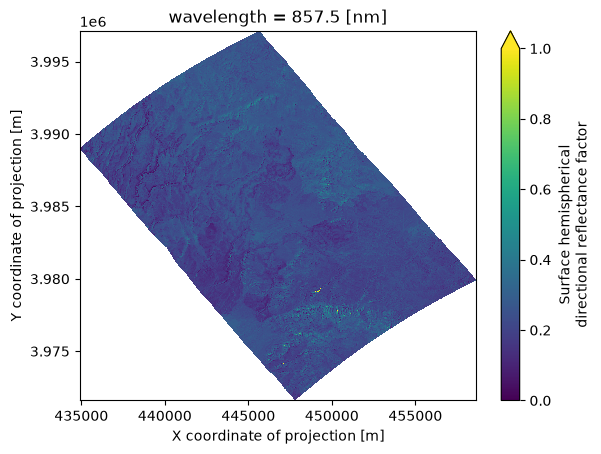

In [33]:
airborne_ds["reflectance"]["reflectance"].sel({"wavelength":860}, method="nearest").plot(vmin=0, vmax=1)

## Reproject into lat/lons
We need to have lat/lon coordinates for the `point_collocation` package and to match up with PACE, so let's reproject the airborne dataset. I'll do a brief explanation of this part.

Note: memory intensive so using dask, and had to cut off last wavelengths from aviris dataset

In [6]:
# attempting dask
from dask.distributed import Client, LocalCluster
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/skyecaplan/proxy/8787/status,
Dashboard: /user/skyecaplan/proxy/8787/status,Workers: 4
Total threads: 4,Total memory: 29.08 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36963,Workers: 0
Dashboard: /user/skyecaplan/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40441,Total threads: 1
Dashboard: /user/skyecaplan/proxy/43955/status,Memory: 7.27 GiB
Nanny: tcp://127.0.0.1:40813,


2026-08-27 16:48:34,569 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:35235 (pid=930) exceeded 95% memory budget. Restarting...
2026-08-27 16:48:34,670 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:35235 (pid=930) is slow to accept SIGTERM; sending SIGKILL
2026-08-27 16:48:34,769 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:35235 (pid=930) is slow to accept SIGTERM; sending SIGKILL
2026-08-27 16:48:35,031 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:35235' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('rechunk-merge-db012e2c6d57564e5103cc706785d252', 21, 0, 0), ('rechunk-merge-db012e2c6d57564e5103cc706785d252', 60, 0, 0), ('rechunk-merge-db012e2c6d57564e5103cc706785d252', 32, 0, 0), ('rechunk-merge-db012e2c6d57564e5103cc706785d252', 44, 0, 0), ('rechunk-merge-db012e2c6d57564e5103cc706785d252', 10, 0, 0), ('rechunk-merge-db012e2c6d57564e5103cc706785d252', 67, 0, 0), ('re

In [ ]:
air_rfl = airborne_ds["reflectance"]["reflectance"].rio.write_crs(airborne_ds["transverse_mercator"].attrs["crs_wkt"])
air_rfl = air_rfl.chunk({"wavelength":5, "easting":-1, "northing":-1})
air_rfl_84 = air_rfl.rio.reproject("EPSG:4326")

2026-08-27 16:48:35,176 - distributed.nanny - WARNING - Restarting worker (status=Status.running)
2026-08-27 16:49:56,970 - distributed.nanny - WARNING - Restarting worker (status=Status.running)
2026-08-27 16:51:26,040 - distributed.nanny - WARNING - Restarting worker (status=Status.running)


In [12]:
client.close()

We can use rasterio and rioxarray to reproject the data into WGS 84 using `rio.reproject`. We use WGS 84/EPSG 4326 because we will be using L2 PACE data, which is mapped to that system.

In [7]:
# NOTE: memory intensive, might have to subset wavelengths first?
# started at ~500 mb, went up to 24 GB...
air_rfl_84 = air_rfl.rio.reproject("EPSG:4326")
air_rfl_84

<xarray.DataArray 'reflectance' (wavelength: 424, y: 2093, x: 2401)> Size: 9GB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(424, 2093, 2401), dtype=float32)
Coordinates:
  * wavelength           (wavelength) float32 2kB 381.4 386.4 ... 2.499e+03
  * y                    (y) float64 17kB 36.12 36.12 36.12 ... 35.89 35.89
  * x                    (x) float64 19kB -117.7 -117.7 -117.7 ... -117.5 -117.5
    transverse_mercator  int64 8B 0
Attributes:
    _QuantizeBitGroomNumberOfSignificantDigits:  5
    long_name:                                   Surface hemispherical direct...
    orthorectified:                              True

In [8]:
air_rfl_84 = air_rfl_84.rename({"x":"longitude", "y":"latitude"})

## Grab some random points to use for validation 

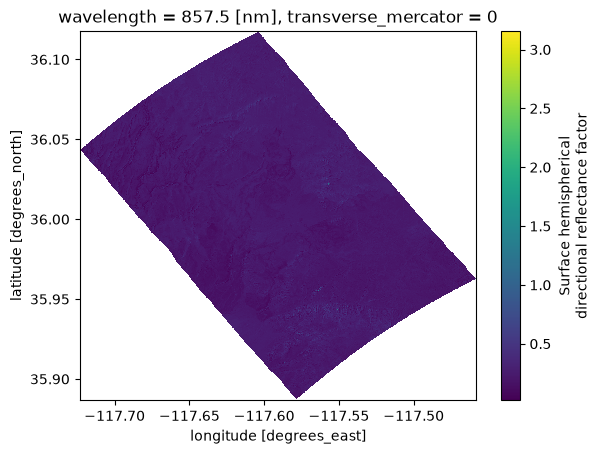

In [9]:
air_rfl_84.sel({"wavelength":860}, method="nearest").plot(x="longitude", y="latitude")

In [ ]:
air_rfl.rio.crs

In [ ]:
air_rfl